In [1]:
def main(datasources, start_date, end_date):
    """
    买卖盘深度变化协同性因子
    Depth Change Correlation Factor

    因子定义
    --------
    1. 分别计算五档买方深度和五档卖方深度：

       BidDepth =
           bid_volume1 + ... + bid_volume5

       AskDepth =
           ask_volume1 + ... + ask_volume5

    2. 计算分钟深度对数变化：

       DeltaBidDepth_m =
           log(1 + BidDepth_m)
           - log(1 + BidDepth_{m-1})

       DeltaAskDepth_m =
           log(1 + AskDepth_m)
           - log(1 + AskDepth_{m-1})

    3. 每日因子：

       factor =
           Corr(
               DeltaBidDepth_m,
               DeltaAskDepth_m
           )

    经济含义
    --------
    因子越高，买卖盘两侧深度变化越同步，说明盘口流动性
    更倾向于整体扩张或整体收缩，而不是出现明显单边分化。

    返回
    ----
    DataFrame，且仅包含：
        date
        instrument
        factor
    """

    import numpy as np
    import pandas as pd
    import dai

    # ============================================================
    # 1. 数据源检查
    # ============================================================
    if "bar1m" not in datasources:
        raise KeyError(
            "datasources中缺少bar1m数据源映射。"
        )

    bar1m_table = datasources["bar1m"]

    # ============================================================
    # 2. 日期范围
    # ============================================================
    target_start = pd.to_datetime(
        start_date,
        errors="raise"
    ).normalize()

    target_end = pd.to_datetime(
        end_date,
        errors="raise"
    ).normalize()

    if target_end < target_start:
        raise ValueError(
            "end_date不能早于start_date。"
        )

    query_start = target_start.strftime(
        "%Y-%m-%d 00:00:00"
    )

    query_end = (
        target_end
        + pd.Timedelta(days=1)
        - pd.Timedelta(seconds=1)
    ).strftime(
        "%Y-%m-%d %H:%M:%S"
    )

    # ============================================================
    # 3. SQL构造原始因子
    #
    # 上午和下午分别计算LAG，避免跨午休形成虚假的
    # 分钟深度变化。
    # ============================================================
    sql = f"""
    WITH valid_snapshot AS (
        SELECT
            date,
            instrument,
            date::DATE AS trading_day,

            CASE
                WHEN
                    strftime(date, '%H:%M') >= '09:30'
                    AND strftime(date, '%H:%M') <= '11:30'
                THEN 1

                WHEN
                    strftime(date, '%H:%M') >= '13:00'
                    AND strftime(date, '%H:%M') <= '15:00'
                THEN 2

                ELSE NULL
            END AS session_id,

            (
                CAST(
                    COALESCE(bid_volume1, 0)
                    AS DOUBLE
                )
                +
                CAST(
                    COALESCE(bid_volume2, 0)
                    AS DOUBLE
                )
                +
                CAST(
                    COALESCE(bid_volume3, 0)
                    AS DOUBLE
                )
                +
                CAST(
                    COALESCE(bid_volume4, 0)
                    AS DOUBLE
                )
                +
                CAST(
                    COALESCE(bid_volume5, 0)
                    AS DOUBLE
                )
            ) AS bid_depth,

            (
                CAST(
                    COALESCE(ask_volume1, 0)
                    AS DOUBLE
                )
                +
                CAST(
                    COALESCE(ask_volume2, 0)
                    AS DOUBLE
                )
                +
                CAST(
                    COALESCE(ask_volume3, 0)
                    AS DOUBLE
                )
                +
                CAST(
                    COALESCE(ask_volume4, 0)
                    AS DOUBLE
                )
                +
                CAST(
                    COALESCE(ask_volume5, 0)
                    AS DOUBLE
                )
            ) AS ask_depth

        FROM {bar1m_table}

        WHERE
            bid_price1 IS NOT NULL
            AND ask_price1 IS NOT NULL

            AND bid_price1 > 0
            AND ask_price1 > 0
            AND ask_price1 >= bid_price1

            AND (
                (
                    strftime(date, '%H:%M') >= '09:30'
                    AND strftime(date, '%H:%M') <= '11:30'
                )
                OR
                (
                    strftime(date, '%H:%M') >= '13:00'
                    AND strftime(date, '%H:%M') <= '15:00'
                )
            )
    ),

    valid_book AS (
        SELECT
            date,
            instrument,
            trading_day,
            session_id,
            bid_depth,
            ask_depth

        FROM valid_snapshot

        WHERE
            session_id IS NOT NULL

            AND bid_depth IS NOT NULL
            AND ask_depth IS NOT NULL

            AND bid_depth > 0
            AND ask_depth > 0
    ),

    lagged_book AS (
        SELECT
            date,
            instrument,
            trading_day,
            session_id,

            bid_depth,
            ask_depth,

            LAG(
                bid_depth,
                1
            ) OVER (
                PARTITION BY
                    instrument,
                    trading_day,
                    session_id

                ORDER BY
                    date
            ) AS lag_bid_depth,

            LAG(
                ask_depth,
                1
            ) OVER (
                PARTITION BY
                    instrument,
                    trading_day,
                    session_id

                ORDER BY
                    date
            ) AS lag_ask_depth

        FROM valid_book
    ),

    minute_dynamics AS (
        SELECT
            date,
            instrument,
            trading_day,
            session_id,

            CASE
                WHEN
                    bid_depth > 0
                    AND lag_bid_depth > 0
                THEN
                    LOG(
                        1.0 + bid_depth
                    )
                    -
                    LOG(
                        1.0 + lag_bid_depth
                    )
                ELSE NULL
            END AS bid_depth_change,

            CASE
                WHEN
                    ask_depth > 0
                    AND lag_ask_depth > 0
                THEN
                    LOG(
                        1.0 + ask_depth
                    )
                    -
                    LOG(
                        1.0 + lag_ask_depth
                    )
                ELSE NULL
            END AS ask_depth_change

        FROM lagged_book

        WHERE
            lag_bid_depth IS NOT NULL
            AND lag_ask_depth IS NOT NULL

            AND lag_bid_depth > 0
            AND lag_ask_depth > 0
    ),

    valid_dynamics AS (
        SELECT
            date,
            instrument,
            trading_day,
            session_id,

            bid_depth_change,
            ask_depth_change

        FROM minute_dynamics

        WHERE
            bid_depth_change IS NOT NULL
            AND ask_depth_change IS NOT NULL

            AND ABS(bid_depth_change) <= 10.0
            AND ABS(ask_depth_change) <= 10.0
    ),

    daily_moments AS (
        SELECT
            trading_day,
            instrument,

            COUNT(*) AS valid_minutes,

            VAR_POP(
                CAST(
                    bid_depth_change
                    AS DOUBLE
                )
            ) AS bid_change_variance,

            VAR_POP(
                CAST(
                    ask_depth_change
                    AS DOUBLE
                )
            ) AS ask_change_variance,

            COVAR_POP(
                CAST(
                    bid_depth_change
                    AS DOUBLE
                ),
                CAST(
                    ask_depth_change
                    AS DOUBLE
                )
            ) AS depth_change_covariance

        FROM valid_dynamics

        GROUP BY
            trading_day,
            instrument
    ),

    raw_factor AS (
        SELECT
            trading_day,
            instrument,
            valid_minutes,

            CASE
                WHEN
                    bid_change_variance IS NOT NULL
                    AND bid_change_variance > 1e-16

                    AND ask_change_variance IS NOT NULL
                    AND ask_change_variance > 1e-16

                    AND depth_change_covariance IS NOT NULL
                THEN
                    depth_change_covariance
                    /
                    (
                        SQRT(
                            bid_change_variance
                            * ask_change_variance
                        )
                        + 1e-16
                    )
                ELSE NULL
            END AS factor

        FROM daily_moments
    )

    SELECT
        trading_day::DATETIME AS date,
        instrument,
        factor

    FROM raw_factor

    WHERE
        valid_minutes >= 100
        AND factor IS NOT NULL

    ORDER BY
        date,
        instrument
    """

    factor_df = dai.query(
        sql,
        filters={
            "date": [
                query_start,
                query_end
            ]
        },
        compression=True
    ).df()

    # ============================================================
    # 4. 清理原始因子
    # ============================================================
    if factor_df.empty:
        factor_df = pd.DataFrame(
            columns=[
                "date",
                "instrument",
                "factor"
            ]
        )

    factor_df["date"] = pd.to_datetime(
        factor_df["date"],
        errors="coerce"
    ).dt.normalize()

    factor_df["instrument"] = (
        factor_df["instrument"]
        .astype(str)
        .str.strip()
    )

    factor_df["factor"] = pd.to_numeric(
        factor_df["factor"],
        errors="coerce"
    ).replace(
        [np.inf, -np.inf],
        np.nan
    )

    factor_df = factor_df.dropna(
        subset=[
            "date",
            "instrument",
            "factor"
        ]
    )

    factor_df = factor_df[
        (factor_df["date"] >= target_start)
        & (factor_df["date"] <= target_end)
    ].copy()

    factor_df = factor_df.drop_duplicates(
        subset=[
            "date",
            "instrument"
        ],
        keep="last"
    )

    # 理论上相关系数应处于[-1, 1]，额外裁剪防止数值误差。
    factor_df["factor"] = factor_df[
        "factor"
    ].clip(
        lower=-1.0,
        upper=1.0
    )

    # ============================================================
    # 5. 读取中证1000历史股票池
    # ============================================================
    stock_pool = dai.query(
        """
        SELECT
            date,
            instrument

        FROM bigalpha_2026_instruments
        """,
        filters={
            "date": [
                query_start,
                query_end
            ]
        },
        compression=True
    ).df()

    if stock_pool.empty:
        raise ValueError(
            "目标区间中证1000股票池为空。"
        )

    stock_pool["date"] = pd.to_datetime(
        stock_pool["date"],
        errors="coerce"
    ).dt.normalize()

    stock_pool["instrument"] = (
        stock_pool["instrument"]
        .astype(str)
        .str.strip()
    )

    stock_pool = stock_pool.dropna(
        subset=[
            "date",
            "instrument"
        ]
    )

    stock_pool = stock_pool[
        (stock_pool["date"] >= target_start)
        & (stock_pool["date"] <= target_end)
    ].copy()

    stock_pool = stock_pool.drop_duplicates(
        subset=[
            "date",
            "instrument"
        ],
        keep="last"
    )

    if stock_pool.empty:
        raise ValueError(
            "清理后的中证1000股票池为空。"
        )

    # ============================================================
    # 6. 对齐股票池
    # ============================================================
    result = pd.merge(
        stock_pool,
        factor_df[
            [
                "date",
                "instrument",
                "factor"
            ]
        ],
        how="left",
        on=[
            "date",
            "instrument"
        ]
    )

    # ============================================================
    # 7. 每日横截面缺失值填补
    #
    # 使用当日有效股票的中位数填补少量缺失。
    # 某日完全没有有效值时，最后填0。
    # ============================================================
    daily_median = (
        result
        .groupby("date")["factor"]
        .transform("median")
    )

    result["factor"] = (
        result["factor"]
        .fillna(daily_median)
        .fillna(0.0)
    )

    # ============================================================
    # 8. 每日1%—99%缩尾
    # ============================================================
    def daily_winsorize(series):
        valid = series.dropna()

        if len(valid) < 20:
            return series

        lower_bound = valid.quantile(0.01)
        upper_bound = valid.quantile(0.99)

        return series.clip(
            lower=lower_bound,
            upper=upper_bound
        )

    result["factor"] = (
        result
        .groupby("date")["factor"]
        .transform(
            daily_winsorize
        )
    )

    # ============================================================
    # 9. 每日横截面标准化
    # ============================================================
    def daily_zscore(series):
        mean_value = series.mean()
        std_value = series.std(ddof=0)

        if (
            std_value is None
            or not np.isfinite(std_value)
            or std_value <= 1e-12
        ):
            return pd.Series(
                np.zeros(
                    len(series),
                    dtype=float
                ),
                index=series.index
            )

        return (
            series - mean_value
        ) / std_value

    result["factor"] = (
        result
        .groupby("date")["factor"]
        .transform(
            daily_zscore
        )
    )

    result["factor"] = pd.to_numeric(
        result["factor"],
        errors="coerce"
    ).replace(
        [np.inf, -np.inf],
        np.nan
    ).fillna(0.0)

    # ============================================================
    # 10. 最终输出
    # ============================================================
    result = (
        result[
            [
                "date",
                "instrument",
                "factor"
            ]
        ]
        .drop_duplicates(
            subset=[
                "date",
                "instrument"
            ],
            keep="last"
        )
        .sort_values(
            [
                "date",
                "instrument"
            ]
        )
        .reset_index(
            drop=True
        )
    )

    # ============================================================
    # 11. 严格完整性检查
    # ============================================================
    expected_columns = [
        "date",
        "instrument",
        "factor"
    ]

    if result.columns.tolist() != expected_columns:
        raise ValueError(
            "输出必须且仅包含"
            "date、instrument、factor。"
        )

    if result.empty:
        raise ValueError(
            "最终买卖盘深度变化协同性因子为空。"
        )

    if result.duplicated(
        subset=[
            "date",
            "instrument"
        ]
    ).any():
        raise ValueError(
            "存在重复date-instrument观测。"
        )

    if result["factor"].isna().any():
        raise ValueError(
            "factor存在NaN。"
        )

    factor_values = result[
        "factor"
    ].to_numpy(
        dtype=float
    )

    if not np.isfinite(
        factor_values
    ).all():
        raise ValueError(
            "factor存在inf或-inf。"
        )

    return result

[2026-07-23 17:15:28] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-23 17:15:32] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-23 17:15:33] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-23 17:15:33] [info     ] ========== 数据检查 ==========
[2026-07-23 17:15:33] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset_lf', 'current_ratio_lf', 'netflow_amount_main', 'netflow_amount_rate_main', 'net_active_buy_amount_main', 'beta_000300SH_22', 'list_days']
[2026-07-23 17:15:33] [info    

时段,IC
2024-01-15~2024-02-08,-0.0017
2024-09-24~2024-10-08,0.0276

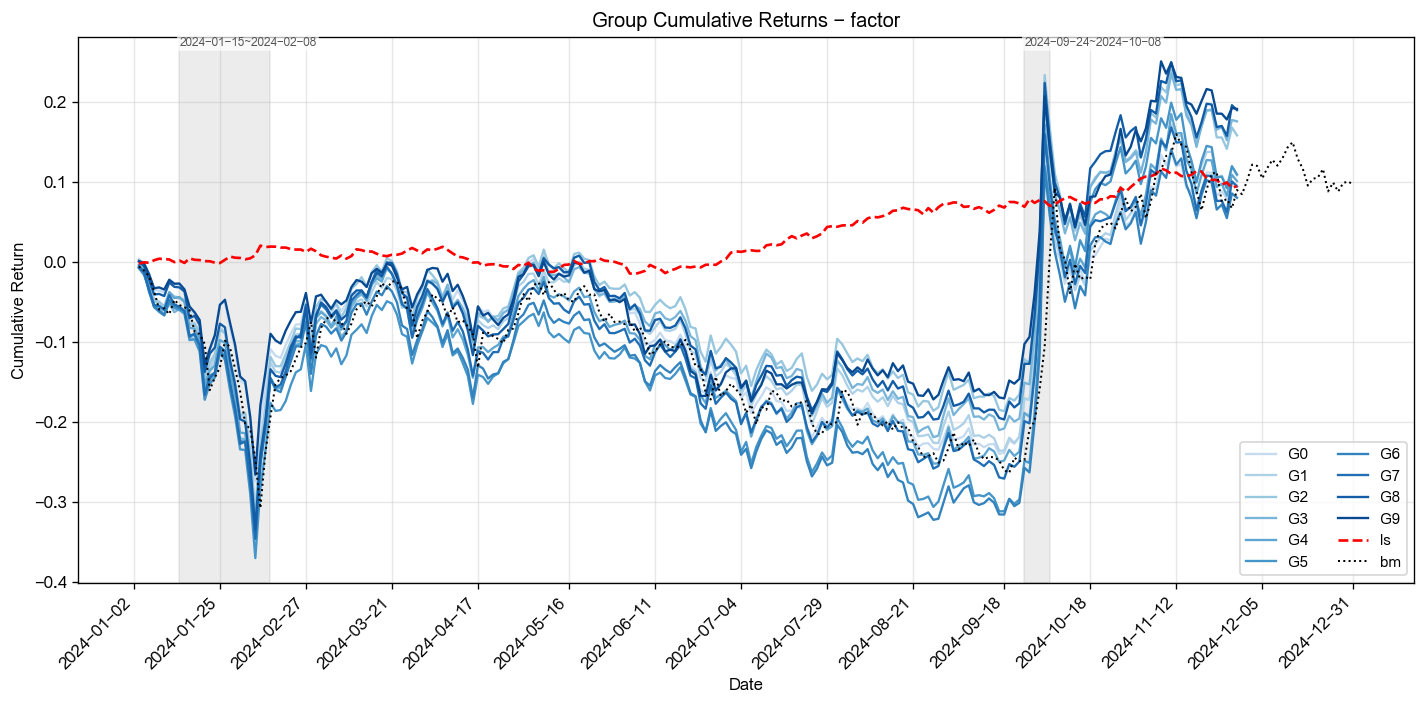
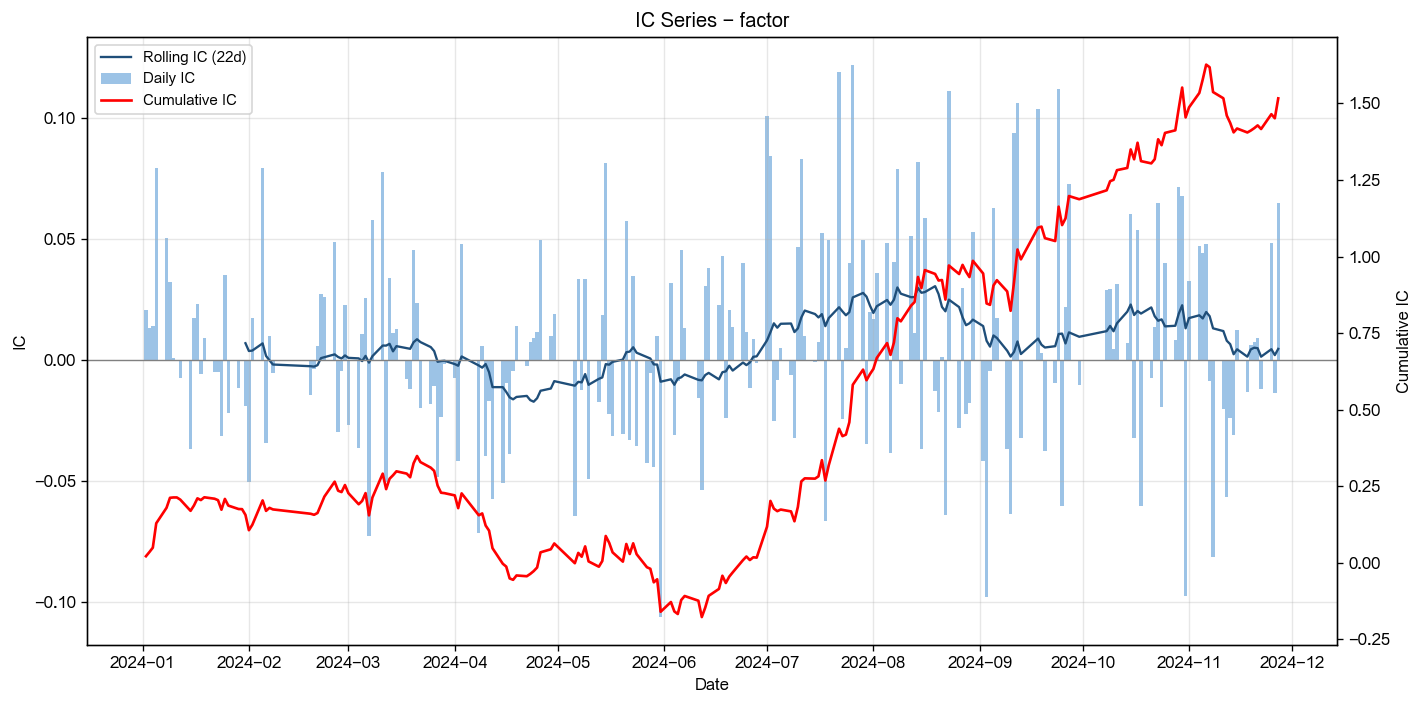
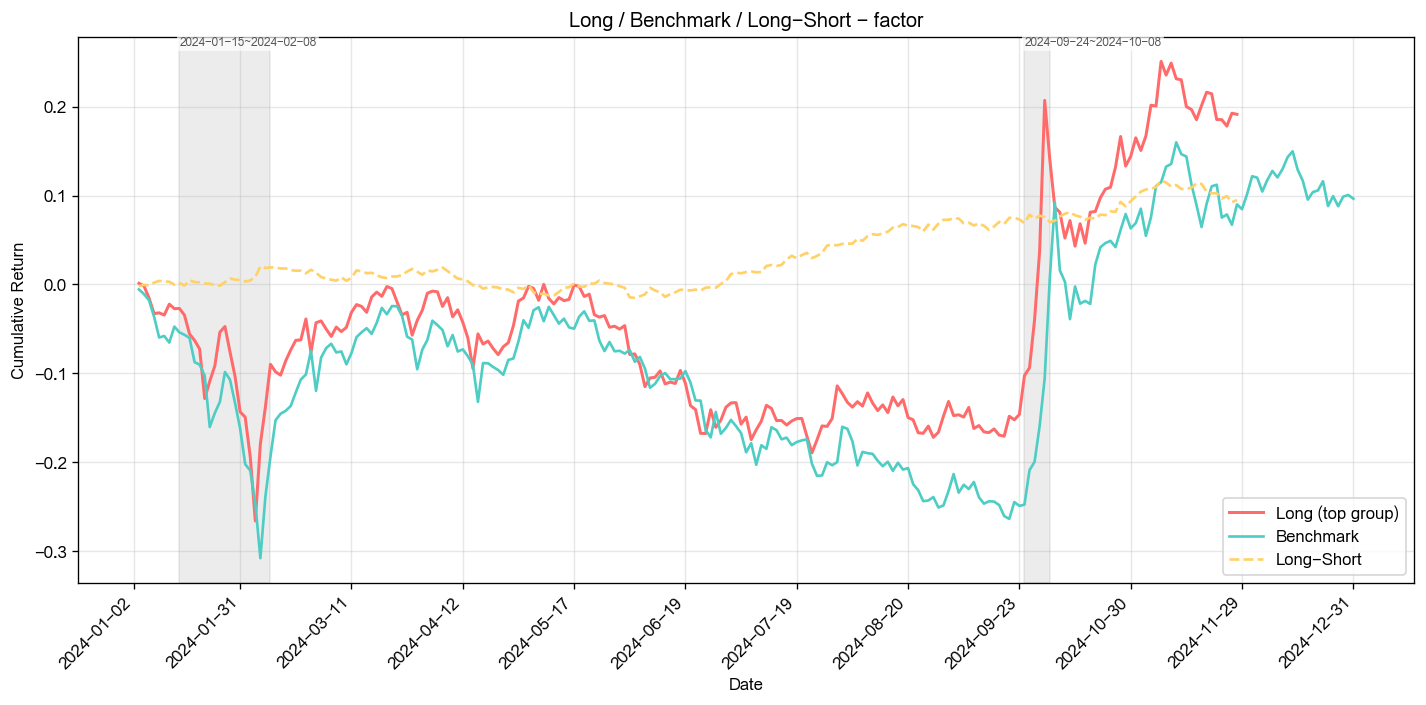
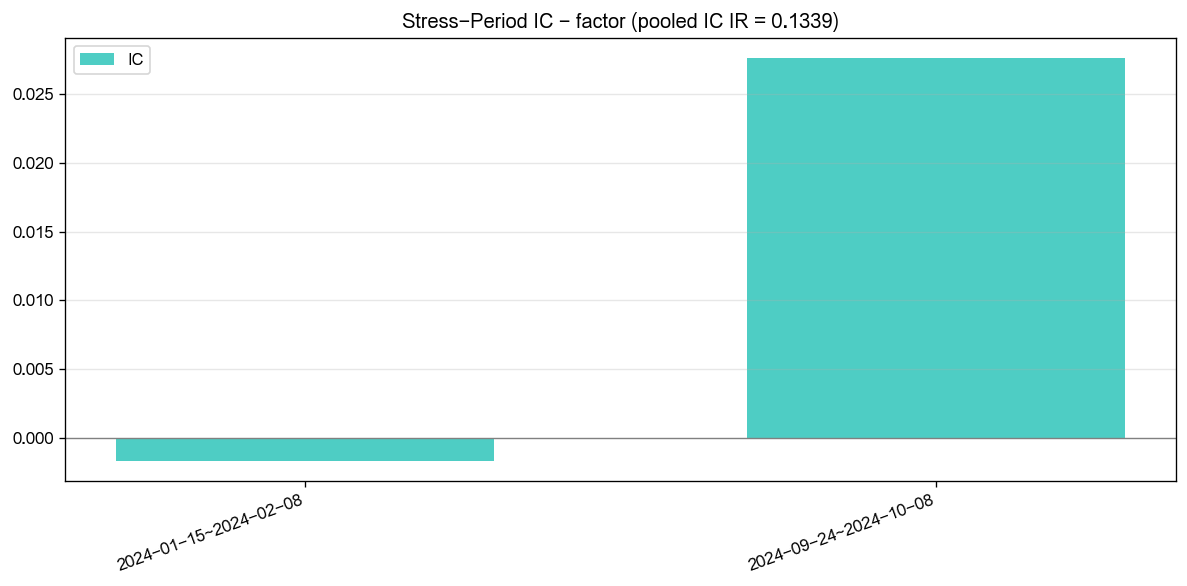
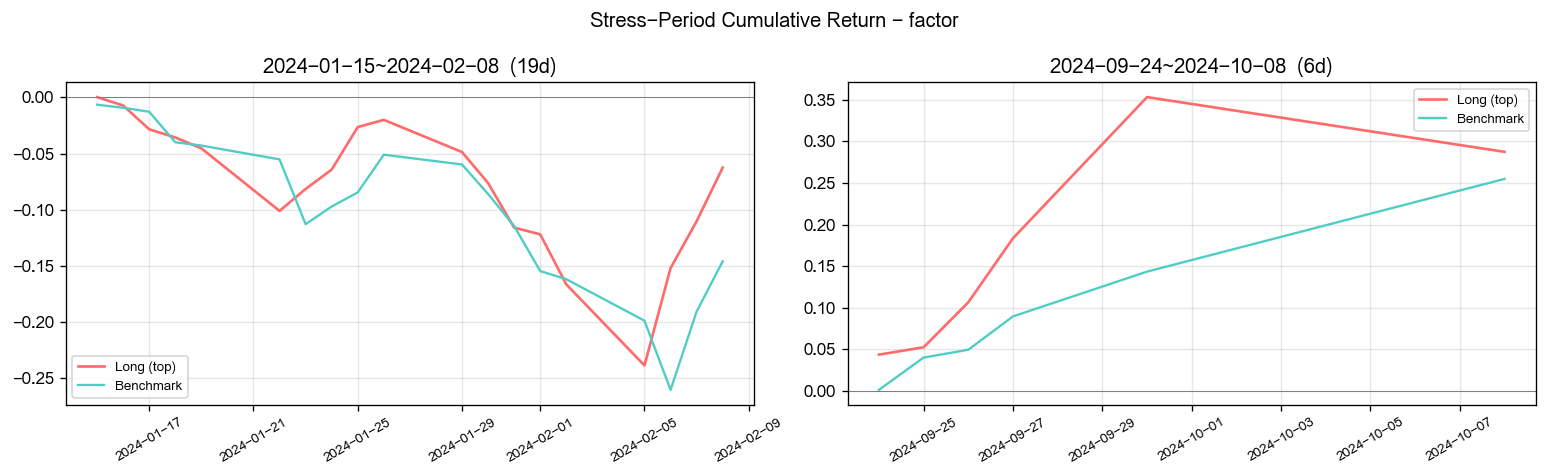

[2026-07-23 17:15:46] [info     ] ========== 因子池回归 ==========
[2026-07-23 17:15:47] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-23 17:15:47] [info     ] 获取收益率数据, 耗时: 0.9269 秒
[2026-07-23 17:15:48] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.3428 秒
[2026-07-23 17:15:48] [info     ] 统计 回归结果, 耗时: 0.0828 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9217,0.0446,0.0232,1.0000
2,amount,1.6899,0.0184,0.0109,1.0000
3,factor,1.5879,0.0060,0.0038,1.0000
4,netflow_amount_rate_main,1.5574,0.0100,0.0064,1.0000
5,gross_profit_rate_ttm,1.5201,0.0070,0.0046,1.0000
6,netflow_amount_main,1.5136,0.0252,0.0166,1.0000
7,net_profit_rate_ttm,1.4449,0.0040,0.0028,0.8000
8,pb,1.4423,0.0095,0.0066,1.0000
9,bias_20,1.4046,0.0291,0.0207,0.9000
10,cci_14,1.3860,0.0339,0.0245,1.0000

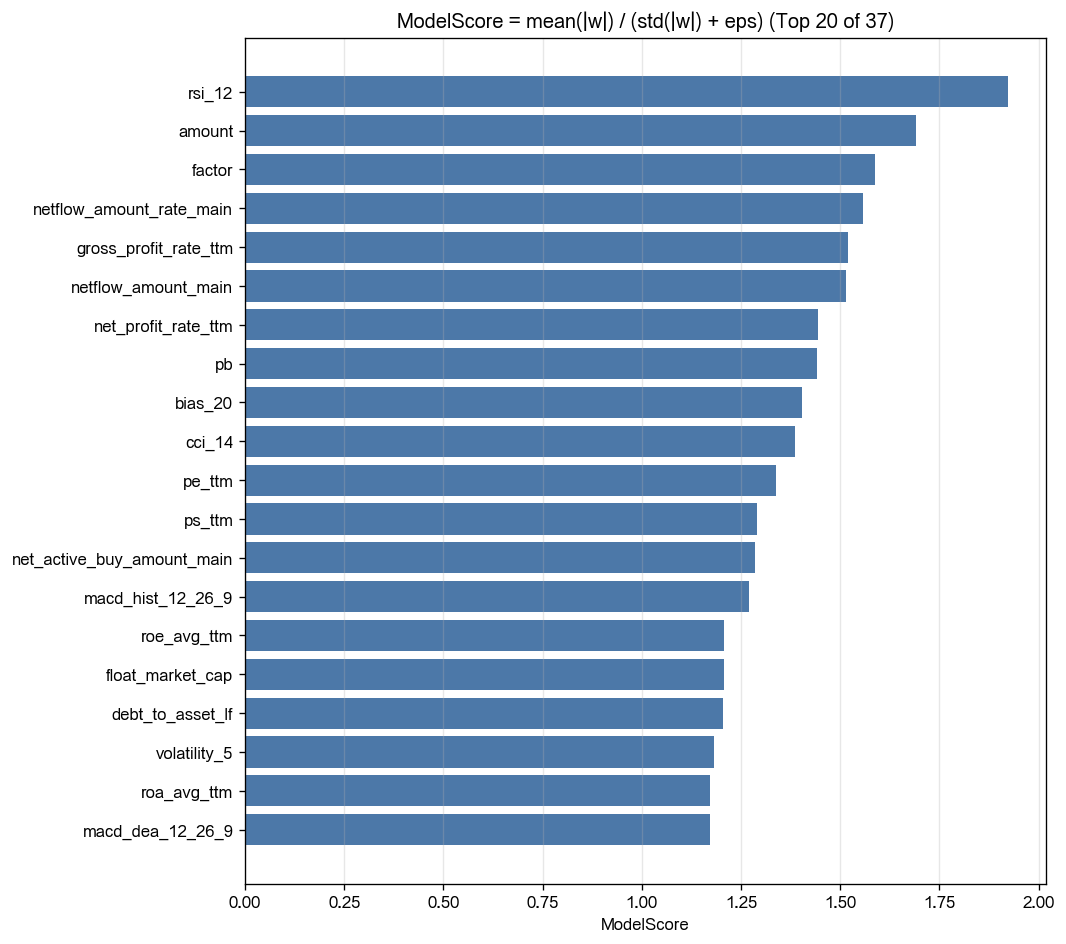
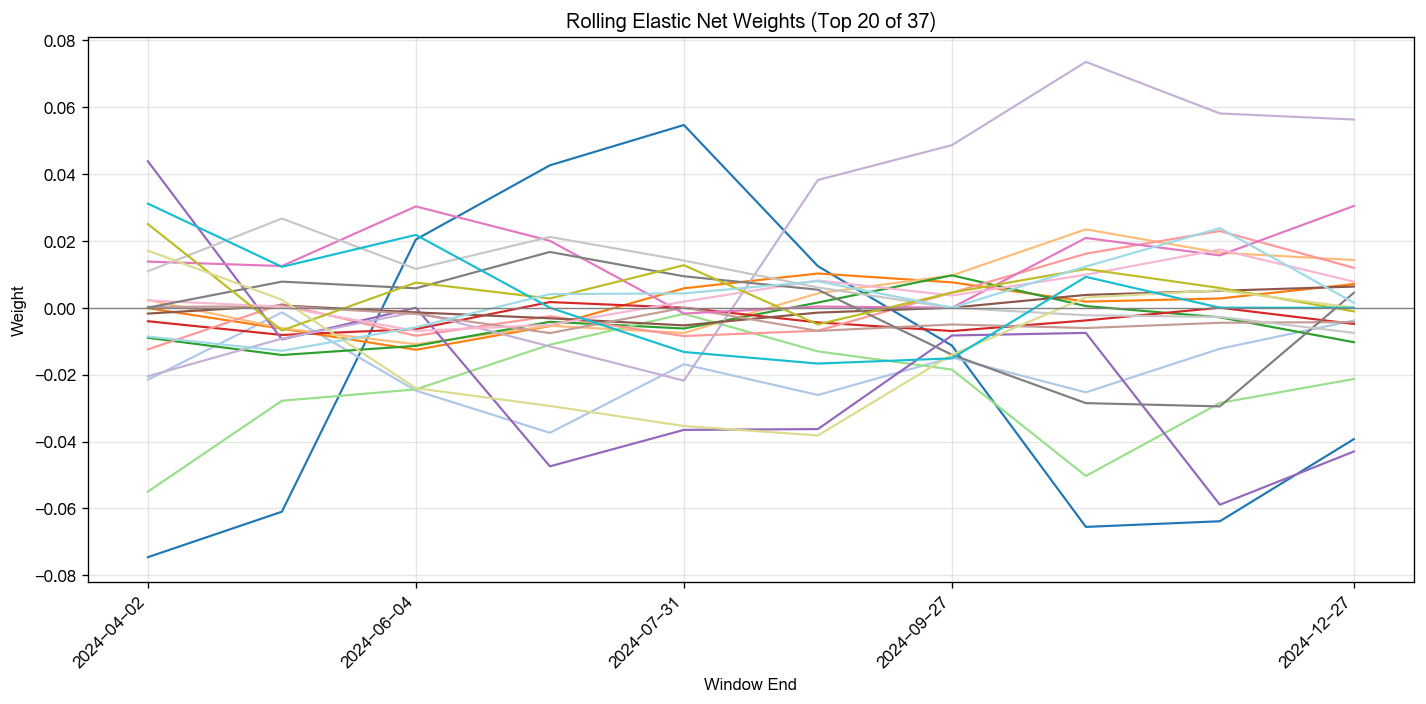
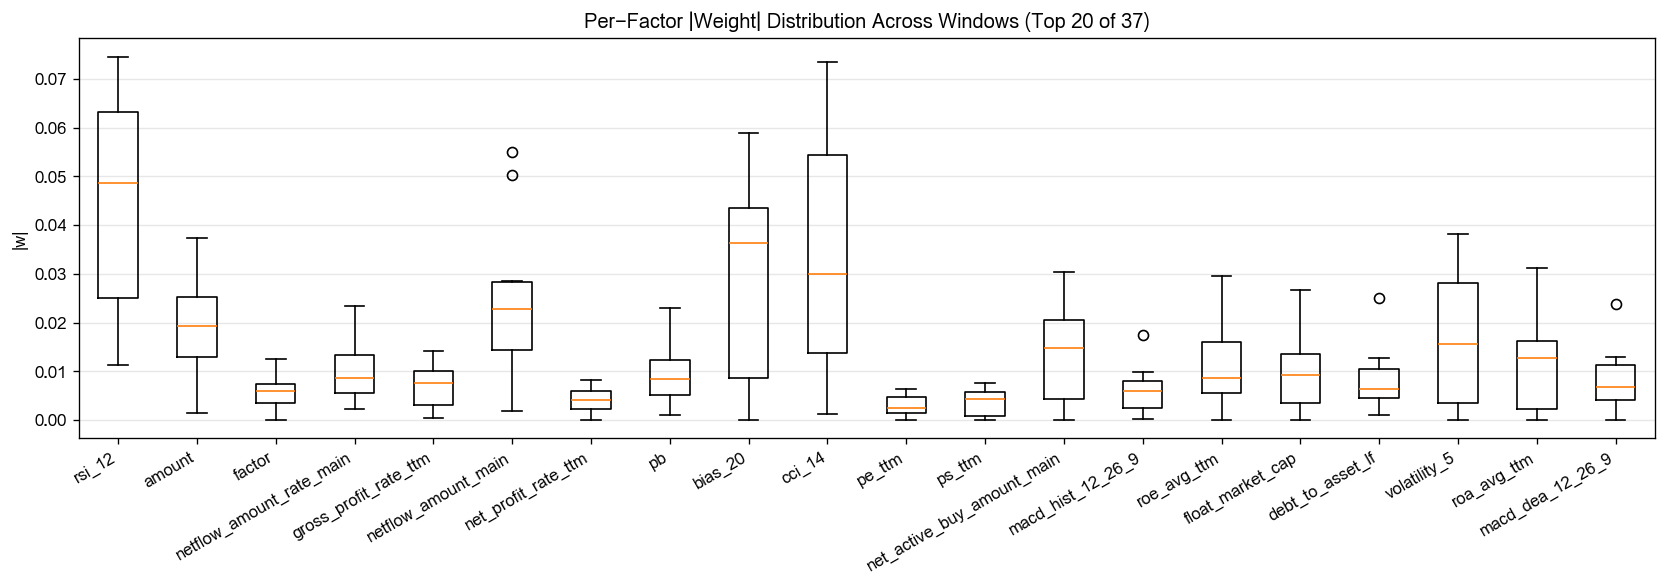
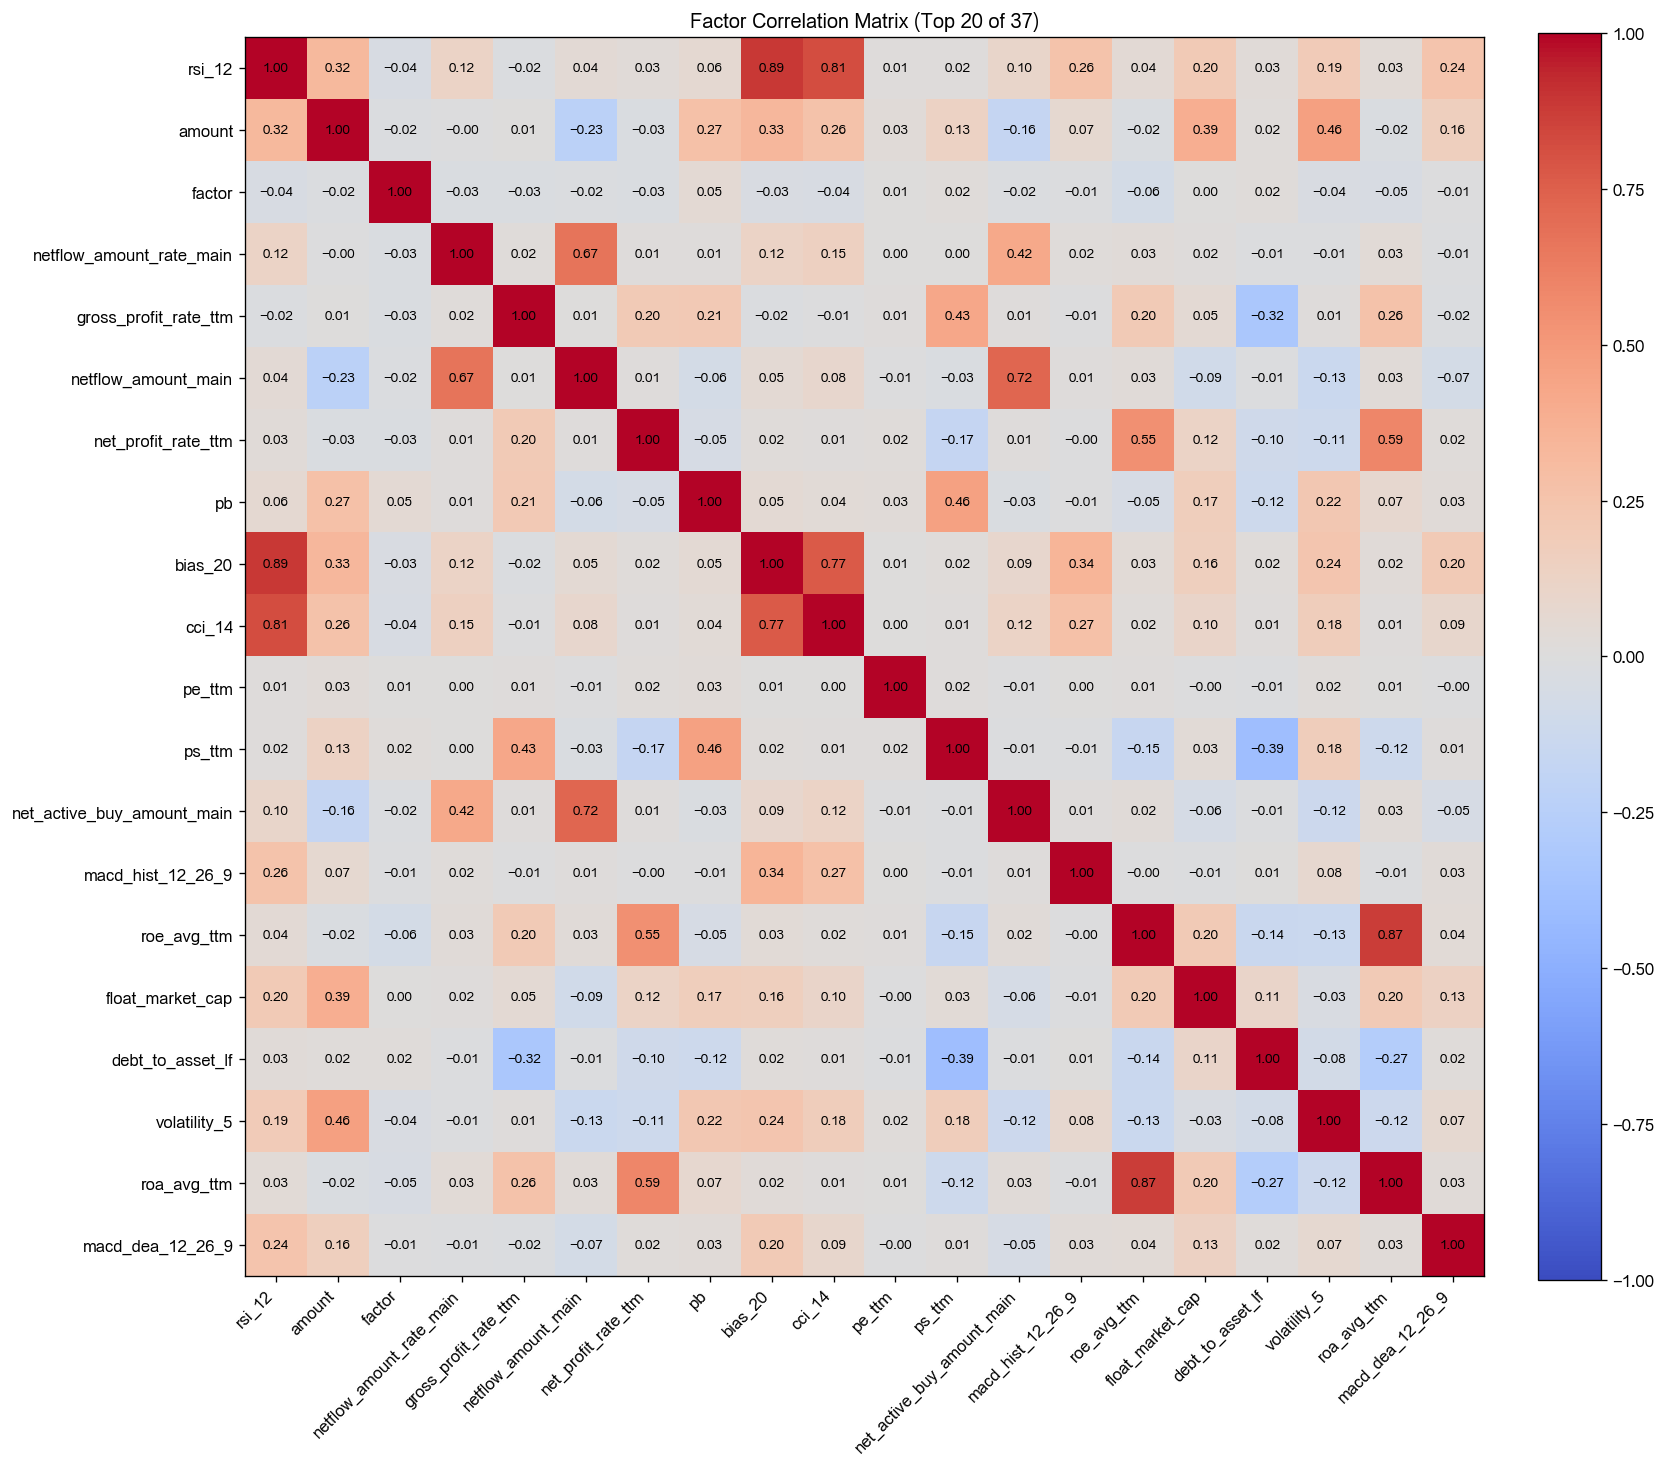

[2026-07-23 17:15:51] [warning  ] 返回的Outputs实例(size=35396198) 大于 64K, 将不会被缓存
[2026-07-23 17:15:51] [info     ] bigalpha_eval.v4 运行完成 [18.907s].


{'raw_factor':              date instrument    factor
 0      2024-01-02  000006.SZ  1.662101
 1      2024-01-02  000012.SZ  2.090680
 2      2024-01-02  000016.SZ -0.030182
 3      2024-01-02  000019.SZ  1.529206
 4      2024-01-02  000025.SZ -0.022735
 ...           ...        ...       ...
 241995 2024-12-31  688766.SH -0.722483
 241996 2024-12-31  688776.SH  0.247950
 241997 2024-12-31  688779.SH  1.319328
 241998 2024-12-31  688789.SH -0.299278
 241999 2024-12-31  688798.SH -0.052661
 
 [242000 rows x 3 columns],
 'process_factor':              date instrument    factor
 0      2024-01-02  000006.SZ  0.182669
 1      2024-01-02  000012.SZ  1.334852
 2      2024-01-02  000016.SZ -0.766561
 3      2024-01-02  000019.SZ  0.929306
 4      2024-01-02  000025.SZ -0.065518
 ...           ...        ...       ...
 241995 2024-12-31  688766.SH -0.291944
 241996 2024-12-31  688776.SH  0.691792
 241997 2024-12-31  688779.SH  1.297249
 241998 2024-12-31  688789.SH  0.139448
 241999 2024-12-31

In [2]:
from bigmodule import M
import dai
import pandas as pd

datasources = {
    "bar1m": "bigalpha_2026_stock_bar1m"
}

start_date = "2024-01-01 00:00:00"
end_date = "2024-12-31 23:59:59"

factor_data = main(
    datasources=datasources,
    start_date=start_date,
    end_date=end_date
)

factor_pool = dai.query(
    """
    SELECT *
    FROM bigalpha_2026_factorlib
    """,
    filters={
        "date": [
            start_date,
            end_date
        ]
    },
    compression=True
).df()

factor_pool["date"] = pd.to_datetime(
    factor_pool["date"],
    errors="coerce"
).dt.normalize()

factor_pool["instrument"] = (
    factor_pool["instrument"]
    .astype(str)
    .str.strip()
)

M.bigalpha_eval._latest(
    factor_data=factor_data,
    factor_pool=factor_pool,
    start_date=start_date,
    end_date=end_date,
    process_pools=False,
    show=True
)